In [47]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))

In [55]:
from src.quantum_hrp import quantum_feature_map_density, average_density_matrix, frobenius_distance, compute_distance_matrix
from src.hrp_ordering import hrp_order_from_distance, hrp_order_from_correlation


In [56]:
returns = pd.read_csv("../../data/returns.csv", index_col=0)
features = np.load("../../data/features.npy")

In [57]:
corr = returns.corr()

In [58]:
# Classical HRP (tu función original está bien)
order_classical = hrp_order_from_correlation(corr)
corr_classical = corr.iloc[order_classical, :].iloc[:, order_classical]

# Quantum HRP - usando funciones del paper
alpha = 2.0
N = features.shape[0]
rhos = []

for i in range(N):
    rho = average_density_matrix(features[i], alpha=alpha)
    rhos.append(rho)

D_quantum = compute_distance_matrix(rhos)
order_quantum = hrp_order_from_distance(D_quantum)
corr_quantum = corr.iloc[order_quantum, :].iloc[:, order_quantum]



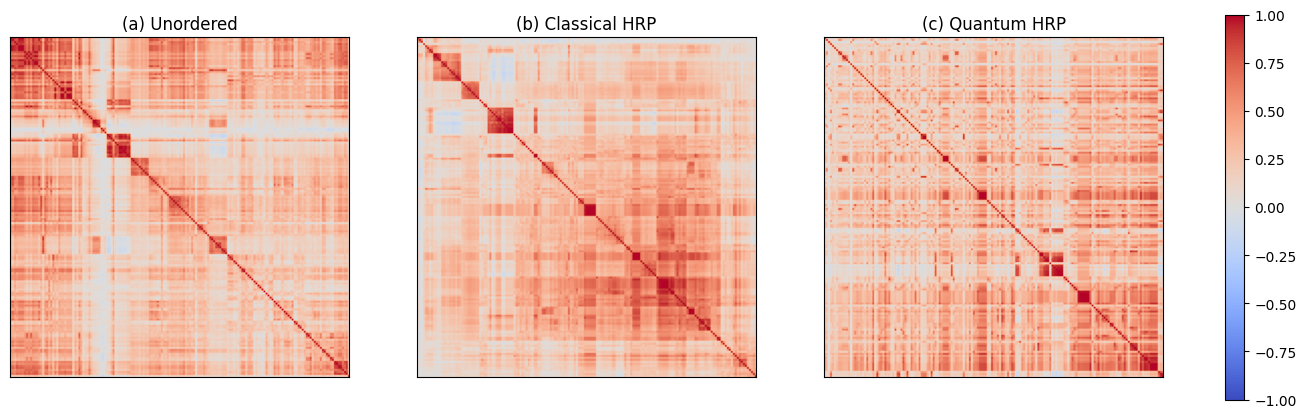

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs[0].imshow(corr, cmap="coolwarm", vmin=-0.25, vmax=1)
axs[0].set_title("(a) Unordered")

axs[1].imshow(corr_classical, cmap="coolwarm", vmin=-0.25, vmax=1)
axs[1].set_title("(b) Classical HRP")

axs[2].imshow(corr_quantum, cmap="coolwarm", vmin=-0.25, vmax=1)
axs[2].set_title("(c) Quantum HRP")

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(axs[0].images[0], ax=axs, fraction=0.02)
plt.savefig("figures/figure3.png", dpi=300)
plt.show()
